# BRIDGE deciphers and interprets regulatory pathogenic mutations
Here we walk through the necessary steps to reproduce the main figures of regulatory pathogenic mutations that disrupt dynamic
RNA–protein interactions across genomic contexts using BRIDGE.

## 1. Load BRIDGE model and compute variant scores
Please download the variant dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset_variant/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the variant scores.

In [ ]:
%%bash
set -euo pipefail

BRIDGE_HOME=../../
cd "$BRIDGE_HOME"
model_save_path=./results/model

python variant_aware.py \
  --ribosnitch \
  --variation_mode before \
  --fasta_sequence_path ./reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/riboSNitches.fasta \
  --Transformer_path ./RBPformer \
  --model_save_path "$model_save_path" \
  --variant_out_file ./reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/ribosnitch_before.txt \
  --device cuda:3


In [ ]:
%%bash
set -euo pipefail

BRIDGE_HOME=../../
cd "$BRIDGE_HOME"
model_save_path=./results/model

python variant_aware.py \
  --ribosnitch \
  --variation_mode after \
  --fasta_sequence_path ./reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/riboSNitches.fasta \
  --Transformer_path ./RBPformer \
  --model_save_path "$model_save_path" \
  --variant_out_file ./reproducibility/ClinVar_TCGA_1000G_resources/ribosnitches/ribosnitch_after.txt \
  --device cuda:3


## 2. Downstream analysis

**Note:**
Running the full pipeline across all variants can be time-consuming.  
To make it easier to reproduce the figures directly, we also provide the precomputed files on `Figshare`.

In [ ]:
import math
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import pandas as pd

# -----------------------------
# File paths
# -----------------------------
base_dir = Path("../ClinVar_TCGA_1000G_resources")
ribosnitch_dir = base_dir / "ribosnitches"

before_raw_fp = ribosnitch_dir / "ribosnitch_before.txt"
before_gt0_fp = ribosnitch_dir / "ribosnitch_before_gt0.txt"

# -----------------------------
# Keep only rows with score > 0
# -----------------------------
before_gt0_fp.parent.mkdir(parents=True, exist_ok=True)
with before_raw_fp.open("r", encoding="utf-8") as fin, before_gt0_fp.open("w", encoding="utf-8") as fout:
    for line in fin:
        # The score is stored in the last column
        score = float(line.rstrip("\n").split("\t")[-1])
        if score >= 0:
            fout.write(line)

In [4]:
def get_match_lines():
    # Use the shared path variables defined earlier (ribosnitch_dir, before_gt0_fp)
    after_mut_fp = ribosnitch_dir / "ribosnitch_after.txt"
    before_mut_fp = before_gt0_fp
    output_fp = ribosnitch_dir / "ribosnitch_after_gt0.txt"

    output_fp.parent.mkdir(parents=True, exist_ok=True)

    # Read `before` lines (excluding the last score column) into a set for fast matching.
    before_mut_set = set()
    with before_mut_fp.open("r", encoding="utf-8") as before_file:
        for line in before_file:
            parts = line.strip().split()
            if len(parts) > 1:
                before_mut_set.add(" ".join(parts[:-1]))

    # Write lines from `after` whose "key" (excluding the last score column) exists in `before`.
    with output_fp.open("w", encoding="utf-8") as out_file:
        with after_mut_fp.open("r", encoding="utf-8") as after_file:
            for line in after_file:
                parts = line.strip().split()
                if len(parts) > 1:
                    match_line = " ".join(parts[:-1])
                    if match_line in before_mut_set:
                        out_file.write(line)

get_match_lines()


In [5]:
from collections import defaultdict
import re

# Initialize a dictionary for disease counts.
disease_counts = defaultdict(int)

# Invalid disease labels.
invalid_labels = {'not_specified', 'not_provided'}

# Read the file and group entries by variant.
variants = defaultdict(list)
with open(before_gt0_fp, 'r') as file:
    for line in file:
        # Extract the variant identifier and the disease field inside [].
        variant_id = line.split()[0]  # Assuming variant_id is the first field of the line.
        match = re.search(r'\[(.*?)\]', line)
        if match:
            # Parse the disease tags and filter invalid labels.
            diseases = [disease for disease in match.group(1).split('|') if disease not in invalid_labels]
            if diseases:
                # Append diseases to the list for this variant.
                variants[variant_id].extend(diseases)

# For each variant, count each disease at most once (deduplicate within variant).
for variant_id, diseases in variants.items():
    # Ensure each variant contributes at most one count per disease.
    unique_diseases = set(diseases)
    for disease in unique_diseases:
        disease_counts[disease] += 1

# Print counts sorted from high to low.
sorted_disease_counts = sorted(disease_counts.items(), key=lambda x: x[1], reverse=True)
for disease, count in sorted_disease_counts:
    print(f'{disease}: {count}')

Hereditary_cancer-predisposing_syndrome: 55
Congenital_disorder_of_glycosylation: 46
Autosomal_recessive_cerebellar_ataxia: 39
Pheochromocytoma: 38
Leigh_syndrome: 37
Acute_intermittent_porphyria: 37
Coenzyme_Q10_deficiency,_primary,_4: 36
Coenzyme_Q10_deficiency,_Spinocerebellar_Ataxia_Type: 36
Cerebral_cavernous_malformations_2: 33
History_of_neurodevelopmental_disorder: 31
Mitochondrial_complex_II_deficiency: 30
Polycystic_kidney_disease,_adult_type: 28
Growth_and_mental_retardation,_mandibulofacial_dysostosis,_microcephaly,_and_cleft_palate: 24
Leukoencephalopathy,_cystic,_without_megalencephaly: 21
Smith-Lemli-Opitz_syndrome: 21
Charcot-Marie-Tooth,_Intermediate: 20
Charcot-Marie-Tooth_disease,_dominant_intermediate_C: 20
Ectodermal_dysplasia,_anhidrotic,_with_T-cell_immunodeficiency,_autosomal_dominant: 20
Spastic_Paraplegia,_Recessive: 19
Primary_Microcephaly_2_With_or_Without_Cortical_Malformations: 18
Primary_autosomal_recessive_microcephaly_2: 18
Tuberous_sclerosis_syndrome: 

In [6]:
# Split impact scores into positive and negative groups
import re
from collections import defaultdict

def calculate_disease_impact_score():
    # File paths
    after_mut_file = ribosnitch_dir / "ribosnitch_after_gt0.txt"
    before_mut_file = before_gt0_fp
    positive_output_file = ribosnitch_dir / "disease_positive_impact_score.txt"
    negative_output_file = ribosnitch_dir / "disease_negative_impact_score.txt"
    
    # Target disease list to match
    diseases = [
        "Hereditary_cancer-predisposing_syndrome",
        "Congenital_disorder_of_glycosylation",
        "Autosomal_recessive_cerebellar_ataxia",
        "Pheochromocytoma",
        "Leigh_syndrome",
        "Acute_intermittent_porphyria",
        "Coenzyme_Q10_deficiency,_Spinocerebellar_Ataxia_Type",
        "Coenzyme_Q10_deficiency,_primary,_4",
        "Cerebral_cavernous_malformations_2",
        "History_of_neurodevelopmental_disorder",
        "Mitochondrial_complex_II_deficiency"
    ]

    # Initialize containers for scores
    positive_scores = defaultdict(list)
    negative_scores = defaultdict(list)
    
    # Read the before_mut file and store scores by variant key and disease label
    before_data = {}
    with open(before_mut_file, 'r') as before_file:
        for line in before_file:
            parts = line.strip().split()
            disease_info = re.search(r"\[(.*?)\]", line)
            if len(parts) > 2 and disease_info:
                # Extract all disease tags
                disease_tags = disease_info.group(1).replace(" ", "_").split('|')
                variant_key = " ".join(parts[:3])  # Use the first three fields of the variant as the key
                score = float(parts[-1])
                
                # Keep entries that match the target diseases
                for disease in diseases:
                    if any(disease in tag for tag in disease_tags):
                        before_data.setdefault(variant_key, {}).setdefault(disease, score)
    
    # Read the after_mut file and compute impact scores
    with open(after_mut_file, 'r') as after_file:
        for line in after_file:
            parts = line.strip().split()
            disease_info = re.search(r"\[(.*?)\]", line)
            if len(parts) > 2 and disease_info:
                # Extract all disease tags
                disease_tags = disease_info.group(1).replace(" ", "_").split('|')
                variant_key = " ".join(parts[:3])
                after_score = float(parts[-1])
                
                # Check disease match and compute delta (after - before)
                for disease in diseases:
                    if any(disease in tag for tag in disease_tags) and disease in before_data.get(variant_key, {}):
                        before_score = before_data[variant_key][disease]
                        impact_score = after_score - before_score
                        
                        # Store positive/negative scores separately
                        if impact_score > 0:
                            positive_scores[disease].append(impact_score)
                        elif impact_score < 0:
                            negative_scores[disease].append(impact_score)
    
    # Write aggregated results to output files
    with open(positive_output_file, 'w') as pos_file, open(negative_output_file, 'w') as neg_file:
        for disease, scores in positive_scores.items():
            if scores:
                avg_positive_score = sum(scores) / len(scores)
                pos_file.write(f"{disease}\t{avg_positive_score:.4f}\n")
        
        for disease, scores in negative_scores.items():
            if scores:
                avg_negative_score = sum(scores) / len(scores)
                neg_file.write(f"{disease}\t{avg_negative_score:.4f}\n")

calculate_disease_impact_score()

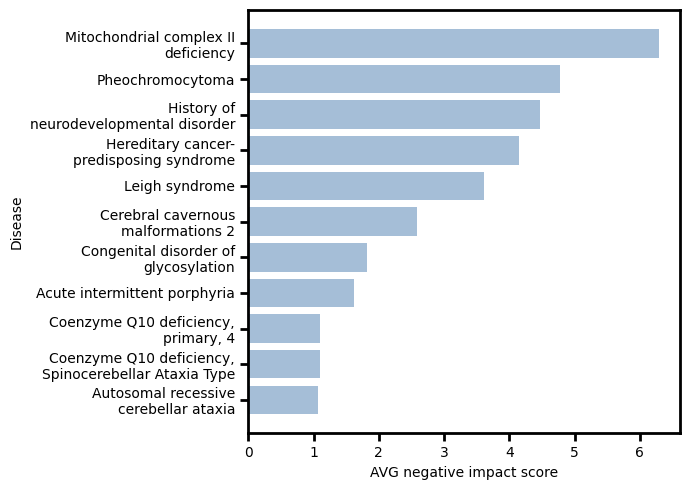

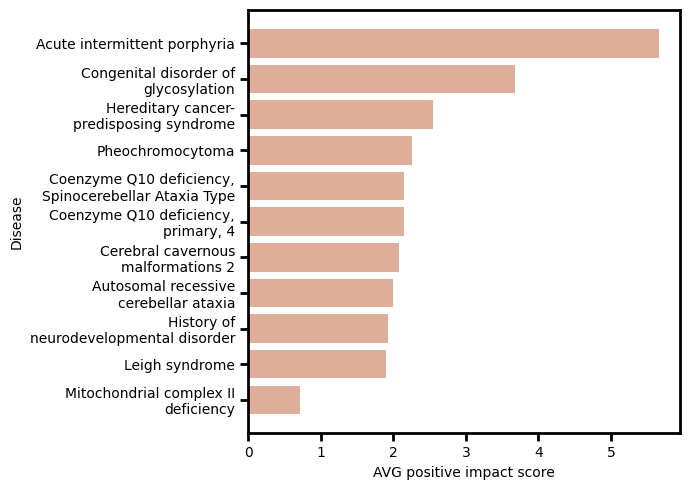

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def plot_disease_bar(in_txt, out_pdf, bar_color, xlab_text, use_abs=False, wrap_width=28):
    # Allow passing either str paths or Path objects
    in_txt = str(in_txt)
    out_pdf = str(out_pdf)

    df = pd.read_csv(
        in_txt,
        sep=r"\s+|\t",
        engine="python",
        header=None,
        names=["Disease", "score"],
    )

    df["value"] = df["score"].abs() if use_abs else df["score"]
    df["Disease"] = (
        df["Disease"]
        .str.replace("_", " ", regex=False)
        .str.replace(r"\s*,\s*", ", ", regex=True)
    )
    df = df.sort_values("value", ascending=False)

    # Wrap long disease names so labels don't overlap
    df["Disease_wrapped"] = df["Disease"].apply(lambda s: "\n".join(textwrap.wrap(s, width=wrap_width)))

    plt.figure(figsize=(7, 5))
    plt.barh(df["Disease_wrapped"], df["value"], color=bar_color)
    plt.gca().invert_yaxis()
    plt.xlabel(xlab_text)
    plt.ylabel("Disease")

    # Match the thicker axis/tick style used in the manuscript figure
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(width=2, length=6)

    plt.tight_layout()
    plt.savefig(out_pdf)
    plt.show()

# 1) Negative impact (raw values are negative; use abs() for bar lengths)
plot_disease_bar(
    ribosnitch_dir / "disease_negative_impact_score.txt",
    ribosnitch_dir / "disease_negative_impact_barplot.pdf",
    "#a5bed7",
    "AVG negative impact score",
    use_abs=True,
)

# 2) Positive impact
plot_disease_bar(
    ribosnitch_dir / "disease_positive_impact_score.txt",
    ribosnitch_dir / "disease_positive_impact_barplot.pdf",
    "#deae9a",
    "AVG positive impact score",
    use_abs=False,
)
